In [1]:
import json
import pathlib
from pprint import pprint

import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns

import bonsai_loop as bl

sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]
sc.set_figure_params(figsize=(5, 5))  # type: ignore[call-arg]

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import inspect

from bonsai_loop.bonsai_lib.bonsai.bonsai_dataprocessing import (  # type: ignore[import]
    loadReconstructedTreeAndData,
)
from bonsai_loop.bonsai_lib.bonsai.bonsai_helpers import (  # type: ignore[import]
    Run_Configs,
)

print(inspect.getsource(loadReconstructedTreeAndData))
print(f"{'─' * 88}")
pprint(Run_Configs.__dict__)

def loadReconstructedTreeAndData(args, tree_folder, reprocess_data=False, all_genes=False, all_ranks=True,
                                 get_cell_info=False, corrected_data=True, rel_to_results=False, no_data_needed=False,
                                 single_process=False, keep_original_data=False, calc_loglik=False, get_data=True,
                                 get_posterior_ltqs=False, otherRanksMinimalInfo=False, verbose=True,
                                 calc_posteriors=True):
    """

    :param args:
    :param tree_folder:
    :param reprocess_data:
    :param all_genes:
    :param all_ranks:
    :param get_cell_info:
    :param corrected_data:
    :param rel_to_results:
    :param no_data_needed:
    :param single_process:
    :param keep_original_data:
    :param calc_loglik:
    :param get_data:
    :param get_posterior_ltqs:
    :param otherRanksMinimalInfo:
    :param verbose:
    :param calc_posteriors: This boolean may be false, even when get_posterior_ltqs i

# Data processing

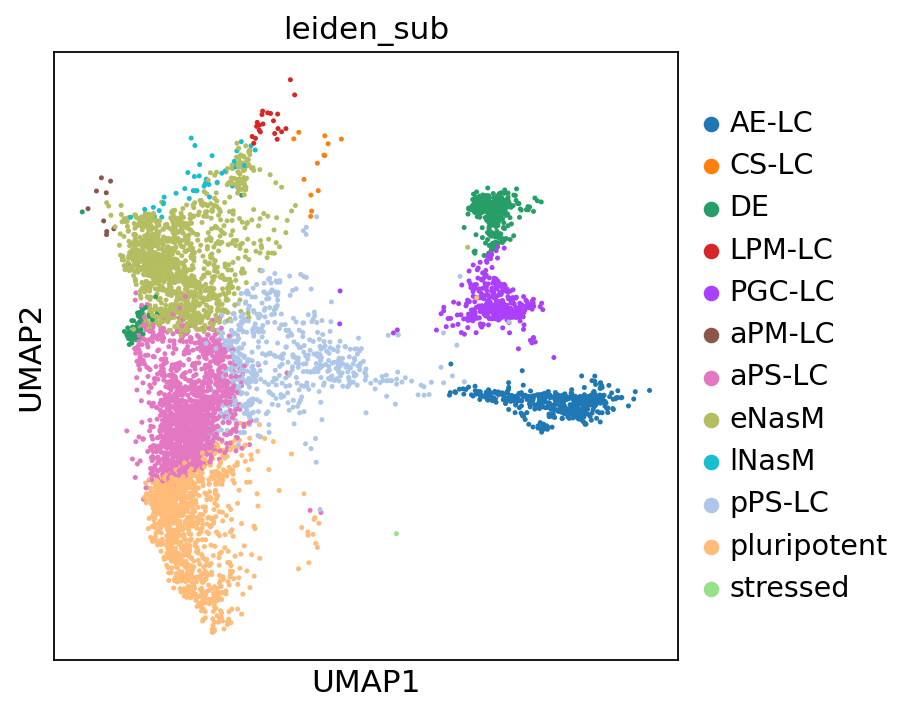

4621

In [3]:
import gc

data_path = pathlib.Path("./data")
adata = sc.read_h5ad(data_path / "adata_timeseries_old_48h-1.h5ad")
meta = pd.read_csv(data_path / "adata_timeseries_old_48h-1_meta.csv", index_col=0)
adata.obs = meta.loc[adata.obs.index]
adata.obsm["X_umap"] = np.array(
    adata.obs.loc[:, ["umap_old_48-96h_x", "umap_old_48-96h_y"]]
)
sc.pl.umap(adata, color=["leiden_sub"])
del meta
bonsai_gastruloid_path = data_path / "Bonsai_48h-1"
gas_bonsai_output_folder = bonsai_gastruloid_path / "final_bonsai_zscore0.75/"
gas_bonsai_config_file = bonsai_gastruloid_path / "used_run_configs.yaml"
gc.collect()

05-02 19:57:39 mp_print INFO 

Reconstructed tree loaded from: 
data/Bonsai_48h-1/final_bonsai_zscore0.75/edgeInfo.txt 
data/Bonsai_48h-1/final_bonsai_zscore0.75/vertInfo.txt
05-02 19:57:39 mp_print INFO 
Init min-dist clustering-tree
05-02 19:57:39 mp_print INFO Clustering has created 2 subtrees, 8 branches still to cut.
05-02 19:57:39 mp_print INFO Clustering has created 4 subtrees, 6 branches still to cut.
05-02 19:57:39 mp_print INFO Clustering has created 8 subtrees, 2 branches still to cut.


Clustering done


<Axes: title={'center': 'bonsai_cluster'}, xlabel='X_bonsai1', ylabel='X_bonsai2'>

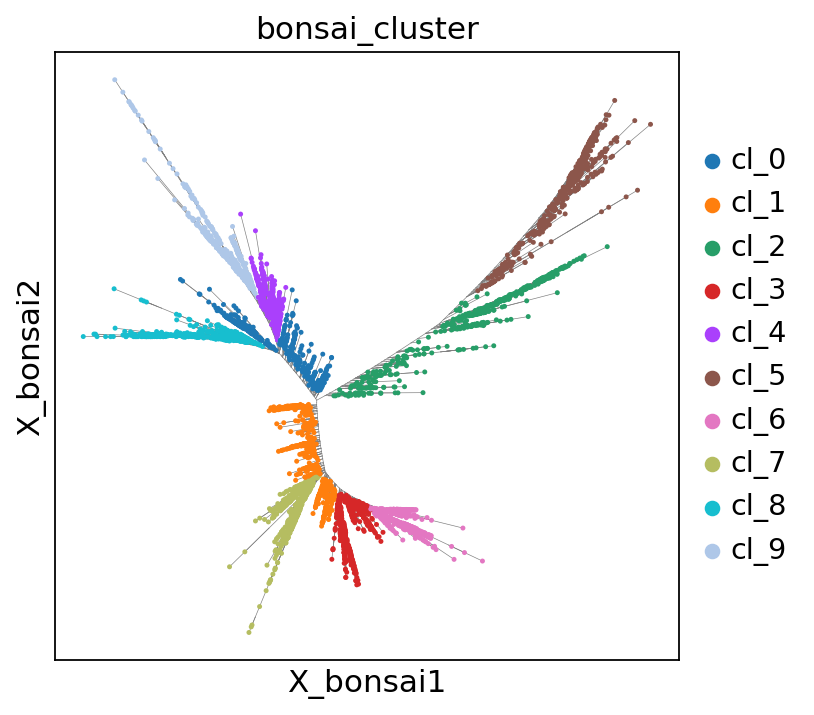

In [4]:
from bonsai_loop.bonsai_lib import bonsai_clustering  # type: ignore[import]

gas_run_configs = Run_Configs(gas_bonsai_config_file)
scData, vert_map = loadReconstructedTreeAndData(
    gas_run_configs,
    gas_bonsai_output_folder,
    rel_to_results=False,
    reprocess_data=False,
    all_ranks=False,
    get_cell_info=True,
    get_posterior_ltqs=True,
)
# compute dsLeafs for dendrogram
scData.tree.root.get_ds_info_for_ladderize()
# reroot
gas_node_id_to_vert_ind = {}
with open(gas_bonsai_output_folder / "vertInfo.txt") as f:
    next(f)
    for line in f:
        parts = line.strip().split("\t")
        gas_node_id_to_vert_ind[parts[2]] = int(parts[0])
new_root = "internal_1880"
scData.tree.reset_root(gas_node_id_to_vert_ind[new_root])
# clustering
f = h5py.File(bonsai_gastruloid_path / "bonsai_vis_data.hdf", "r")
coords = f["layout_coords/node_coords/ly_eq_angle"][:]  # type: ignore[index]
edge_coords = f["layout_coords/edge_coords/ly_eq_angle"][:]  # type: ignore[index]
cell_inds = f["tree_info/cell_inds"][:]  # type: ignore[index]
int_inds = f["tree_info/int_inds"][:]  # type: ignore[index]
metadata = json.loads(f.attrs["metadata_json"])  # type: ignore[index]
gas_cell_ids = metadata["cellIds"]  # type: ignore[index]
gas_vert_to_cell = json.loads(f["vert_info"].attrs["vert_ind_to_cell_inds_json"])  # type: ignore[index]

cell_coords = np.zeros((len(gas_cell_ids), 2))
for vert_idx_str, cell_idx in gas_vert_to_cell.items():
    vert_idx = int(vert_idx_str)
    if isinstance(cell_idx, list):
        for ci in cell_idx:
            cell_coords[ci] = coords[vert_idx]  # type: ignore[index]
    else:
        cell_coords[cell_idx] = coords[vert_idx]  # type: ignore[index]
adata.obsm["X_bonsai"] = cell_coords
f.close()

with open(gas_bonsai_output_folder / "tree.nwk") as f:
    nwk_str = f.read().strip()
all_clusters, _ = bonsai_clustering.get_min_pdists_clustering_from_nwk_str(
    tree_nwk_str=nwk_str, n_clusters=10
)
gas_clusters = all_clusters[f"annot_bnsi_cluster_n{10}"]
cluster_dict = bonsai_clustering.get_cluster_assignments({"annot": gas_clusters})
adata.obs["bonsai_cluster"] = (
    cluster_dict["annot"].reindex(adata.obs.index).fillna("-1")
)
adata.obs["bonsai_cluster"] = adata.obs["bonsai_cluster"].astype(str).astype("category")

if "bonsai_cluster_colors" in adata.uns:
    del adata.uns["bonsai_cluster_colors"]

fig, ax = plt.subplots(figsize=(5, 5))
for e in edge_coords:  # type: ignore[index]
    ax.plot(e[:, 0], e[:, 1], c="gray", lw=0.3, zorder=1)
sc.pl.embedding(
    adata, basis="X_bonsai", color="bonsai_cluster", ax=ax, show=False, s=20, zorder=2
)

# Compute node level and label

In [5]:
node_data_lookup = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["bonsai_cluster"].to_dict(),
)
bl.convergence.compute_bonsai_tree_dendrogram(
    tree=scData.tree,
    node_data_lookup=node_data_lookup,
    ladderize_by_annotated_leaves_only=True,
)

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 293678.49it/s]


In [6]:
# root node should have n_leaves = number of real cells (n=5927)
print(node_data_lookup["internal_1880"])
# a real cell (a leaf) should have n_leaves = 1
print(node_data_lookup["TTTGTTGTCCATTTCA-1_48h"])

┌─────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                   │ value                                        │
├─────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_1880')             │
│ topological_level           │ 195                                          │
│ geometric_level             │ None                                         │
│ identity                    │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                    │ 5927                                         │
│ ordering_value              │ None                                         │
│ dendrogram_coords           │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent │ None                                         │
│ other_props                 │ None                                         │
└─────────────────────────────┴─────────────────────

# Compute delta deviation scores and plot heatmap (ordered by dendrogram position)

In [7]:
# compute ordering
bl.convergence.compute_node_ordering_value(
    tree=scData.tree, node_data_lookup=node_data_lookup, metric="dendrogram"
)
ordering_node_ids = bl.convergence.compute_node_ordering(
    node_data_lookup=node_data_lookup,
    level=0,
    sort_by_identity_first=False,
    ascending=True,
)
# compute delta deviation scores for all nodes
bl.convergence.compute_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup,
    reference_node_ids=ordering_node_ids,
    normalize_by_branch_length=True,
)

compute node ordering using metric dendrogram
compute deviations for 11068 branches × 5927 refs
normalize delta deviation by branch length


/home/stan/Git/bonsai-loop/src/bonsai_loop/convergence.py:771: RuntimeWarning: divide by zero encountered in divide
  delta_d /= t_parents[:, None]


In [8]:
# root node (root has no parent so no deviation score)
print(node_data_lookup["internal_1880"])
print(f"{'─' * 88}")
# a internal node
print(node_data_lookup["internal_720"])
# query some deviation scores for different reference nodes
print(node_data_lookup["internal_720"].delta_deviation_from_parent[0])
print(node_data_lookup["internal_720"].delta_deviation_from_parent[1])
print(f"{'─' * 88}")
# a real cell (a leaf)
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"])
# query some deviation scores
# can query by index
print(node_data_lookup["AAACGAATCTGCAGCG-1_48h"].delta_deviation_from_parent[50])
# or by node id
print(
    node_data_lookup["AAACGAATCTGCAGCG-1_48h"].delta_deviation_from_parent[
        "TTTGGTTTCACAACCA-1_48h"
    ]
)

┌─────────────────────────────┬──────────────────────────────────────────────┐
│ attribute                   │ value                                        │
├─────────────────────────────┼──────────────────────────────────────────────┤
│ tree_node                   │ TreeNode(nodeId='internal_1880')             │
│ topological_level           │ 195                                          │
│ geometric_level             │ None                                         │
│ identity                    │ [(cl_6,0.14), (cl_7,0.13), (cl_3,0.12), ...] │
│ n_leaves                    │ 5927                                         │
│ ordering_value              │ -0.9159482420614774                          │
│ dendrogram_coords           │ (-0.95, -0.9159482420614774)                 │
│ delta_deviation_from_parent │ None                                         │
│ other_props                 │ None                                         │
└─────────────────────────────┴─────────────────────

In [9]:
row_child_node_ids = ordering_node_ids
row_parent_node_ids = [
    node_data_lookup[node_id].tree_node.parentNode.nodeId
    for node_id in row_child_node_ids
]
col_reference_node_ids = ordering_node_ids

deviation_score_matrix = np.vstack(
    [
        node_data_lookup[node_id_child].delta_deviation_from_parent.to_array()
        for node_id_child in row_child_node_ids
    ]
)

In [10]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import TwoSlopeNorm

FONTSIZE = 15
figure_dir = pathlib.Path("notebooks/figures/deviation_score")
if pathlib.Path("data").exists() and not pathlib.Path("notebooks").exists():
    figure_dir = pathlib.Path("figures/deviation_score")
figure_dir.mkdir(parents=True, exist_ok=True)

node_data_lookup_leiden = bl.convergence.compute_tree_node_level_and_label(
    tree=scData.tree,
    node_level_type="topological",
    label_lookup_leaves=adata.obs["leiden_sub"].to_dict(),
)

gas_window_size = 20
gas_cell_types = pd.Categorical(adata.obs["leiden_sub"]).categories
gas_colors = adata.uns["leiden_sub_colors"]


def get_identity_matrix(node_ids, window_size=20):
    identity_matrix = np.zeros((len(gas_cell_types) + 1, len(node_ids)))
    for i, cell_type in enumerate(gas_cell_types):
        cell_type_vec = np.array(
            [
                node_data_lookup_leiden[node_id].identity.get(cell_type, 0)
                if node_data_lookup_leiden[node_id].identity is not None
                else 0
                for node_id in node_ids
            ]
        )
        if window_size < 1:
            res = cell_type_vec
        else:
            res = np.convolve(
                cell_type_vec,
                np.ones(window_size),
                mode="valid",
            )
            margin = int(np.ceil((identity_matrix.shape[1] - res.shape[0]) / 2))
            res = np.pad(res, (margin, margin), mode="constant")
        identity_matrix[i, :] = res[: identity_matrix.shape[1]]
    identity_matrix[-1, :] = 1
    identity_matrix = identity_matrix / np.sum(identity_matrix, axis=0)
    return identity_matrix


reference_identity_matrix = get_identity_matrix(col_reference_node_ids)
parent_identity_matrix = get_identity_matrix(row_parent_node_ids)
child_identity_matrix = get_identity_matrix(row_child_node_ids)

plot_mat = deviation_score_matrix
norm = TwoSlopeNorm(vmin=-0.5, vcenter=0.0, vmax=0.25)
cmap = plt.get_cmap("RdYlBu_r").copy()
cmap.set_bad("white")

g = sns.clustermap(
    plot_mat,
    row_cluster=False,
    col_cluster=False,
    cmap=cmap,
    cbar=True,
    xticklabels=False,
    yticklabels=False,
    norm=norm,
    figsize=(15, 10),
    rasterized=True,
)
ax_hm = g.ax_heatmap
ax_hm.set_aspect("equal")
g.ax_row_dendrogram.set_visible(False)
g.ax_col_dendrogram.set_visible(False)
g.cax.set_visible(False)

ax_hm.set_position([0.16, 0.08, 0.72, 0.72])
pos = ax_hm.get_position()

n = plot_mat.shape[1]
n_rows = plot_mat.shape[0]
x = np.arange(n)
y = np.arange(n_rows)

tick_x = np.arange(0, n, 100)
tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
ax_hm.set_xticks(tick_x)
ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
ax_hm.tick_params(axis="x", which="major", length=3, direction="out")

tick_y = np.arange(0, n_rows, 100)
tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
ax_hm.set_yticks(tick_y)
ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
ax_hm.tick_params(axis="y", which="major", length=3, direction="out")
ax_hm.set_xlabel("reference cells", fontsize=FONTSIZE)
ax_hm.set_ylabel("branches", fontsize=FONTSIZE)
ax_hm.grid(False)

ax_top = g.fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
ax_top.stackplot(x, reference_identity_matrix[:-1, :], colors=gas_colors)
ax_top.set_xlim(ax_hm.get_xlim())
ax_top.axis("off")
ax_top.text(
    1.01,
    0.5,
    "reference identity",
    transform=ax_top.transAxes,
    ha="left",
    va="center",
    rotation=0,
    fontsize=FONTSIZE,
    clip_on=False,
)


def add_left_identity_axis(matrix, x0, label):
    ax = g.fig.add_axes([x0, pos.y0, 0.025, pos.height])
    cumulative = np.cumsum(matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for k in range(cumulative.shape[0]):
        ax.fill_betweenx(y, prev, cumulative[k], color=gas_colors[k])
        prev = cumulative[k]
    ax.set_xlim(1, 0)
    ax.set_ylim(ax_hm.get_ylim())
    ax.axis("off")
    ax.text(
        -0.25,
        0.5,
        label,
        transform=ax.transAxes,
        ha="right",
        va="center",
        rotation=90,
        fontsize=FONTSIZE,
        clip_on=False,
    )
    return ax


add_left_identity_axis(parent_identity_matrix, pos.x0 - 0.095, "parent")
add_left_identity_axis(child_identity_matrix, pos.x0 - 0.04, "child")

ax_top.set_title("Delta deviation (ΔD) score", fontsize=FONTSIZE * 1.25)

mappable = ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cax = g.fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
cb = g.fig.colorbar(mappable, cax=cax, orientation="horizontal")
cb.set_label("delta-D / branch length", fontsize=FONTSIZE, labelpad=4)
cb.ax.tick_params(labelsize=FONTSIZE)
cb.set_ticks([-0.5, 0, 0.25])
cb.set_ticklabels(["-0.5", "0", "0.25"])

g.fig.savefig(
    figure_dir / "level0_delta_deviation_heatmap.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()
gc.collect()

compute depth-first ordering of nodes
root node internal_1880
compute node level and label


11069it [00:00, 263726.92it/s]


96

In [11]:
de_reference_start = 4700
de_reference_stop = 5050
reference_cols = np.arange(de_reference_start, de_reference_stop)
row_scores_to_de = np.nanmean(plot_mat[:, reference_cols], axis=1)

fig = plt.figure(figsize=(15, 10))
ax_hm = fig.add_axes([0.16, 0.08, 0.68, 0.72])
image = ax_hm.imshow(plot_mat, cmap=cmap, norm=norm, interpolation="nearest")
ax_hm.set_aspect("equal")
fig.canvas.draw()
pos = ax_hm.get_position()

n = plot_mat.shape[1]
n_rows = plot_mat.shape[0]
x = np.arange(n)
y = np.arange(n_rows)

tick_x = np.arange(0, n, 100)
tick_x_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_x]
ax_hm.set_xticks(tick_x)
ax_hm.set_xticklabels(tick_x_labels, fontsize=FONTSIZE)
ax_hm.tick_params(axis="x", which="major", length=3, direction="out")

tick_y = np.arange(0, n_rows, 100)
tick_y_labels = [str(int(t)) if t % 500 == 0 else "" for t in tick_y]
ax_hm.set_yticks(tick_y)
ax_hm.set_yticklabels(tick_y_labels, fontsize=FONTSIZE)
ax_hm.tick_params(axis="y", which="major", length=3, direction="out")
ax_hm.yaxis.tick_right()
ax_hm.yaxis.set_label_position("right")
ax_hm.set_xlabel("reference cells", fontsize=FONTSIZE)
ax_hm.set_ylabel("branches", fontsize=FONTSIZE)
ax_hm.grid(False)

ax_triplet = fig.add_axes([0.7, 0.9, 0.12, 0.11])
ax_triplet.plot([0.15, 0.85], [0.78, 0.78], color="black", lw=1.5)
ax_triplet.plot([0.15, 0.5], [0.78, 0.22], color="black", lw=1.0, ls="--")
ax_triplet.plot([0.85, 0.5], [0.78, 0.22], color="black", lw=1.0, ls="--")
ax_triplet.text(0.15, 0.88, "parent", ha="center", va="bottom", fontsize=FONTSIZE)
ax_triplet.text(0.85, 0.88, "child", ha="center", va="bottom", fontsize=FONTSIZE)
ax_triplet.text(0.5, 0.05, "reference", ha="center", va="bottom", fontsize=FONTSIZE)
ax_triplet.set_xlim(0, 1)
ax_triplet.set_ylim(0, 1)
ax_triplet.axis("off")

ax_hm.axvspan(
    de_reference_start - 0.5,
    de_reference_stop - 0.5,
    color="#101520",
    alpha=0.2,
    lw=0,
)
ax_hm.add_patch(
    plt.Rectangle(
        (de_reference_start - 0.5, -0.5),
        de_reference_stop - de_reference_start,
        n_rows,
        fill=False,
        edgecolor="#101520",
        linewidth=1.2,
        alpha=1.0,
    )
)

ax_top = fig.add_axes([pos.x0, pos.y1 + 0.01, pos.width, 0.05])
ax_top.stackplot(x, reference_identity_matrix[:-1, :], colors=gas_colors)
ax_top.set_xlim(ax_hm.get_xlim())
ax_top.axis("off")
ax_top.text(
    1.01,
    0.5,
    "reference identity",
    transform=ax_top.transAxes,
    ha="left",
    va="center",
    rotation=0,
    fontsize=FONTSIZE,
    clip_on=False,
)


def add_left_identity_axis(matrix, x0, label):
    ax = fig.add_axes([x0, pos.y0, 0.025, pos.height])
    cumulative = np.cumsum(matrix[:-1, :], axis=0)
    prev = np.zeros(n_rows)
    for k in range(cumulative.shape[0]):
        ax.fill_betweenx(y, prev, cumulative[k], color=gas_colors[k])
        prev = cumulative[k]
    ax.set_xlim(1, 0)
    ax.set_ylim(ax_hm.get_ylim())
    ax.axis("off")
    ax.text(
        -0.25,
        0.5,
        label,
        transform=ax.transAxes,
        ha="right",
        va="center",
        rotation=90,
        fontsize=FONTSIZE,
        clip_on=False,
    )
    return ax


add_left_identity_axis(parent_identity_matrix, pos.x0 - 0.095, "parent")
add_left_identity_axis(child_identity_matrix, pos.x0 - 0.04, "child")

ax_trace = fig.add_axes([pos.x1 + 0.07, pos.y0, 0.08, pos.height], sharey=ax_hm)
ax_trace.plot(row_scores_to_de, y, color="#279E68", lw=1.0)
ax_trace.axvline(0, color="black", lw=0.6, alpha=1.0, zorder=10)
ax_trace.set_ylim(ax_hm.get_ylim())
ax_trace.set_xlabel("Mean ΔD \nto DE\n(black box)", fontsize=FONTSIZE)
ax_trace.tick_params(axis="x", labelsize=FONTSIZE, length=3, direction="out")
ax_trace.tick_params(axis="y", left=False, labelleft=False)
ax_trace.grid(False)

ax_top.set_title(
    "Delta deviation (ΔD) score toward DE references (black box)",
    fontsize=FONTSIZE * 1.25,
)

mappable = ScalarMappable(norm=norm, cmap=cmap)
mappable.set_array([])
cax = fig.add_axes([pos.x0 - 0.03, 1.01, 0.1, 0.018])
cb = fig.colorbar(mappable, cax=cax, orientation="horizontal")
cb.set_label("delta-D / branch length", fontsize=FONTSIZE, labelpad=4)
cb.ax.tick_params(labelsize=FONTSIZE)
cb.set_ticks([-0.5, 0, 0.25])
cb.set_ticklabels(["-0.5", "0", "0.25"])

fig.savefig(
    figure_dir / "level0_delta_deviation_heatmap_de_trace.png",
    dpi=300,
    bbox_inches="tight",
)
plt.close()
gc.collect()

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: invalid value encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


75

#### Level 0 delta deviation heatmaps and distance-deviation comparison

<table>
  <tr>
    <td><img src="figures/deviation_score/level0_delta_deviation_heatmap.png" alt="Level 0 delta deviation heatmap" width="100%"></td>
    <td><img src="figures/deviation_score/level0_delta_deviation_heatmap_de_trace.png" alt="Level 0 delta deviation heatmap with DE reference trace" width="100%"></td>
    <td><img src="figures/contact_maps/level0_tree_e_minus_embedding_euclidean_dendrogram_order.png" alt="Level 0 tree euclidean minus embedding euclidean" width="100%"></td>
  </tr>
</table>

#### Level 0 delta deviation heatmap (annotated)

<table>
  <tr>
    <td><img src="figures/deviation_score/level0_delta_deviation_heatmap_de_trace_annotated.png" alt="Level 0 delta deviation heatmap annotated" width="50%"></td>
  </tr>
</table>

If we average the deviation score across the reference region for DE, we can see some positive deviation values. Oddly, deviation scores from AE branch are also quite positive.

# Aggregated deviation scores on bonsai tree

In [ ]:
# compute aggretated scores (for each branch, sum across all reference nodes)
agg_sum = bl.convergence.aggregate_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup, method="sum", axis="reference"
)
pprint(dict(list(agg_sum.items())[:5]))
agg_abs_sum = bl.convergence.aggregate_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup, method="abs_sum", axis="reference"
)
pprint(dict(list(agg_abs_sum.items())[:5]))
agg_mean = bl.convergence.aggregate_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup, method="mean", axis="reference"
)
pprint(dict(list(agg_mean.items())[:5]))
agg_abs_mean = bl.convergence.aggregate_delta_deviation_from_parent(
    node_data_lookup=node_data_lookup, method="abs_mean", axis="reference"
)
pprint(dict(list(agg_abs_mean.items())[:5]))

/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/stan/Git/bonsai-loop/.venv/lib/python3.9/site-packages/numpy/_core/_methods.py:127: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


{'internal_1827': 7482.409394676315,
 'internal_1828': 8560.807993841461,
 'internal_1830': 5596.111339004083,
 'internal_1876': 5998.748008446949,
 'internal_1879': 4538.078242841957}
{'internal_1827': 11115.208457825793,
 'internal_1828': 11672.014442435202,
 'internal_1830': 8247.441922936237,
 'internal_1876': 8510.418826641771,
 'internal_1879': 4919.583232614924}
{'internal_1827': 1.262427770318258,
 'internal_1828': 1.4443745560724583,
 'internal_1830': 0.9441726571628282,
 'internal_1876': 1.012105282342998,
 'internal_1879': 0.7656619272552653}
{'internal_1827': 1.8753515197951396,
 'internal_1828': 1.9692955023511391,
 'internal_1830': 1.3915036144653683,
 'internal_1876': 1.4358729250281375,
 'internal_1879': 0.8300292277062467}


In [15]:
# plot aggregated scores on bonsai tree (dendrogram)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize, TwoSlopeNorm

edge_df = scData.tree.get_edge_dataframe()
sources = edge_df["source"].to_list()
targets = edge_df["target"].to_list()

gas_edge_coords_d = np.zeros((len(sources), 3, 2))
for i, (s, t) in enumerate(zip(sources, targets)):
    gas_edge_coords_d[i, 0, :] = node_data_lookup[s].dendrogram_coords
    gas_edge_coords_d[i, 2, :] = node_data_lookup[t].dendrogram_coords
    gas_edge_coords_d[i, 1, 0] = node_data_lookup[s].dendrogram_coords[0]  # type: ignore[index]
    gas_edge_coords_d[i, 1, 1] = node_data_lookup[t].dendrogram_coords[1]  # type: ignore[index]

color_pal = dict(zip(gas_cell_types, gas_colors))
cell_type_node_coords = []
cell_type_node_colors = []
for node_id, node_data in node_data_lookup_leiden.items():
    identity = node_data.identity
    if identity is None or node_id not in node_data_lookup:
        continue
    cell_type = max(identity, key=identity.get)
    cell_type_node_coords.append(node_data_lookup[node_id].dendrogram_coords)
    cell_type_node_colors.append(color_pal[cell_type])
cell_type_node_coords = np.array(cell_type_node_coords)


def plot_dendrogram_edges(ax):
    for e in gas_edge_coords_d:
        ax.plot(e[:, 0], e[:, 1], c="lightgray", lw=0.25, zorder=1)
    ax.set_xlim(-1.0, 1.0)
    ax.set_ylim(-1.0, 1.0)
    ax.axis("off")


def get_score_coords_and_values(score_lookup):
    coords = []
    values = []
    for node_id, score in score_lookup.items():
        coords.append(node_data_lookup[node_id].dendrogram_coords)
        values.append(score)
    values = np.array(values, dtype=float)
    values[~np.isfinite(values)] = np.nan
    return np.array(coords), values


def get_signed_norm(values):
    finite_values = values[np.isfinite(values)]
    vmax = np.nanpercentile(np.abs(finite_values), 99) if len(finite_values) else 1.0
    vmax = vmax if vmax > 0 else 1.0
    return TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)


def get_abs_norm(values):
    finite_values = values[np.isfinite(values)]
    vmax = np.nanpercentile(finite_values, 99) if len(finite_values) else 1.0
    vmax = vmax if vmax > 0 else 1.0
    return Normalize(vmin=0.0, vmax=vmax)


fig, ax = plt.subplots(figsize=(4, 5))
plot_dendrogram_edges(ax)
ax.scatter(
    cell_type_node_coords[:, 0],
    cell_type_node_coords[:, 1],
    c=cell_type_node_colors,
    s=4,
    lw=0,
    rasterized=True,
    zorder=2,
)
ax.set_title("cell type", fontsize=FONTSIZE)
fig.savefig(figure_dir / "dendrogram_cell_type.png", dpi=300, bbox_inches="tight")
plt.close(fig)

score_panels = [
    ("sum", "sum", agg_sum, "RdYlBu_r", get_signed_norm),
    ("abs_sum", "abs sum", agg_abs_sum, "viridis", get_abs_norm),
    ("mean", "mean", agg_mean, "RdYlBu_r", get_signed_norm),
    ("abs_mean", "abs mean", agg_abs_mean, "viridis", get_abs_norm),
]
for filename_tag, title, score_lookup, cmap_name, get_norm in score_panels:
    coords, values = get_score_coords_and_values(score_lookup)
    cmap = plt.get_cmap(cmap_name).copy()
    cmap.set_bad("lightgray")
    norm = get_norm(values)

    fig, ax = plt.subplots(figsize=(4, 5))
    plot_dendrogram_edges(ax)
    ax.scatter(
        coords[:, 0],
        coords[:, 1],
        c=values,
        cmap=cmap,
        norm=norm,
        s=4,
        lw=0,
        rasterized=True,
        zorder=2,
    )
    ax.set_title(title, fontsize=FONTSIZE)
    mappable = ScalarMappable(norm=norm, cmap=cmap)
    mappable.set_array([])
    cb = fig.colorbar(
        mappable, ax=ax, orientation="horizontal", fraction=0.05, pad=0.02
    )
    cb.ax.tick_params(labelsize=FONTSIZE * 0.7)
    cb.set_label("aggregated ΔD", fontsize=FONTSIZE * 0.8)
    fig.savefig(
        figure_dir / f"dendrogram_delta_deviation_{filename_tag}.png",
        dpi=300,
        bbox_inches="tight",
    )
    plt.close(fig)

gc.collect()

5

#### Aggregated delta-D scores on Bonsai dendrogram

<table>
  <tr>
    <td><img src="figures/deviation_score/dendrogram_cell_type.png" alt="Dendrogram cell type" width="100%"></td>
    <td><img src="figures/deviation_score/dendrogram_delta_deviation_sum.png" alt="Dendrogram aggregate delta-D sum" width="100%"></td>
    <td><img src="figures/deviation_score/dendrogram_delta_deviation_abs_sum.png" alt="Dendrogram aggregate absolute delta-D sum" width="100%"></td>
    <td><img src="figures/deviation_score/dendrogram_delta_deviation_mean.png" alt="Dendrogram aggregate delta-D mean" width="100%"></td>
    <td><img src="figures/deviation_score/dendrogram_delta_deviation_abs_mean.png" alt="Dendrogram aggregate absolute delta-D mean" width="100%"></td>
  </tr>
  <tr>
    <td align="center">cell type</td>
    <td align="center">sum</td>
    <td align="center">abs sum</td>
    <td align="center">mean</td>
    <td align="center">abs mean</td>
  </tr>
</table>
